In [1]:
!pip install yfinance

In [2]:
# Import libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns

In [3]:
# Download Apple stock data
web_df = yf.download("AAPL", start="2020-01-01", end="2026-05-04")

[*********************100%***********************]  1 of 1 completed


In [4]:
# Flatten columns
web_df.columns = web_df.columns.get_level_values(0)

In [5]:
# Remove the extra column label ('Price') left after flattening
web_df.columns.name = None

In [6]:
# Save to Excel
web_df.to_excel("aapl.xlsx", index=True)

# Read back from Excel
df = pd.read_excel(r"C:\Users\META\Downloads\aapl_stock_data.xlsx", index_col=0)

### Data Preprocessing

In [7]:
# Check data
print(df.head())

                Close       High        Low       Open     Volume
Date                                                             
2020-01-02  72.333893  72.394101  71.091199  71.344069  135480400
2020-01-03  71.630653  72.389273  71.406681  71.563221  146322800
2020-01-06  72.201408  72.239942  70.503546  70.754014  118387200
2020-01-07  71.861855  72.466338  71.642697  72.211056  108872000
2020-01-08  73.017838  73.318877  71.565621  71.565621  132079200


In [8]:
# Ensure Date is a proper index
df.index = pd.to_datetime(df.index)

# Ensure proper date ordering
df = df.sort_index()

In [9]:
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.333893,72.394101,71.091199,71.344069,135480400
2020-01-03,71.630653,72.389273,71.406681,71.563221,146322800
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200


In [10]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1591 entries, 2020-01-02 to 2026-05-01
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1591 non-null   float64
 1   High    1591 non-null   float64
 2   Low     1591 non-null   float64
 3   Open    1591 non-null   float64
 4   Volume  1591 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 74.6 KB


In [11]:
# Check missing values
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [12]:
# Check for duplicated rows
df.duplicated().sum()

np.int64(0)

### Exploratory Data Analysis

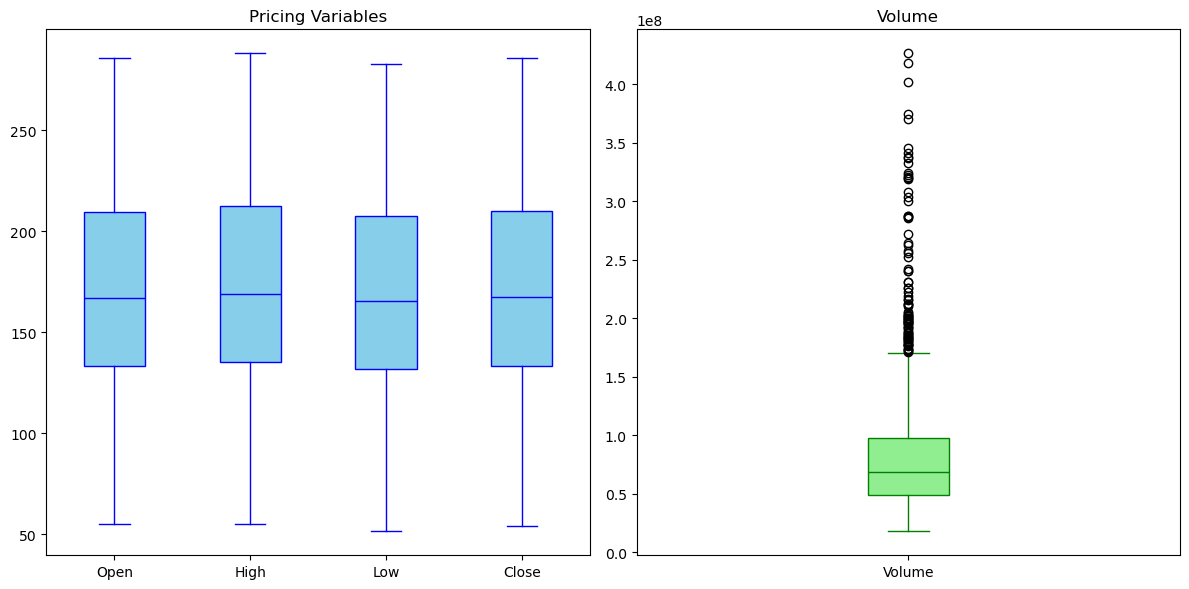

In [13]:
# Check for outliers

# Pricing variables
price_columns = ['Open', 'High', 'Low', 'Close']

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Boxplot for pricing variables
axes[0].boxplot(
    [df[col].dropna() for col in price_columns],
    patch_artist=True,
    boxprops=dict(facecolor='skyblue', color='blue'),
    medianprops=dict(color='blue'),
    whiskerprops=dict(color='blue'),
    capprops=dict(color='blue')
)

# Set labels and title
axes[0].set_title('Pricing Variables')
axes[0].set_xticklabels(price_columns)

# Boxplot for Volume
axes[1].boxplot(
    df['Volume'].dropna(),
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen', color='green'),
    medianprops=dict(color='green'),
    whiskerprops=dict(color='green'),
    capprops=dict(color='green')
)

# Set title and label
axes[1].set_title('Volume')
axes[1].set_xticklabels(['Volume'])

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

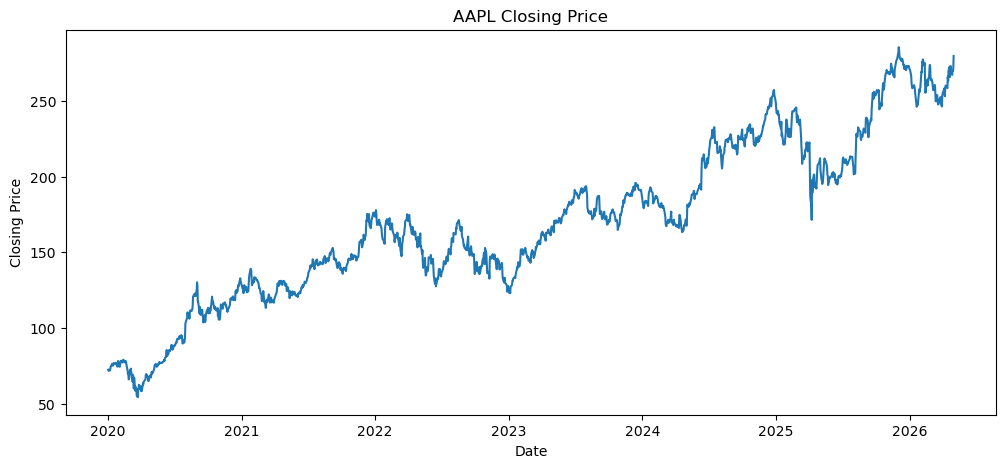

In [14]:
# Closing price line plot
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Close'])
plt.title('AAPL Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

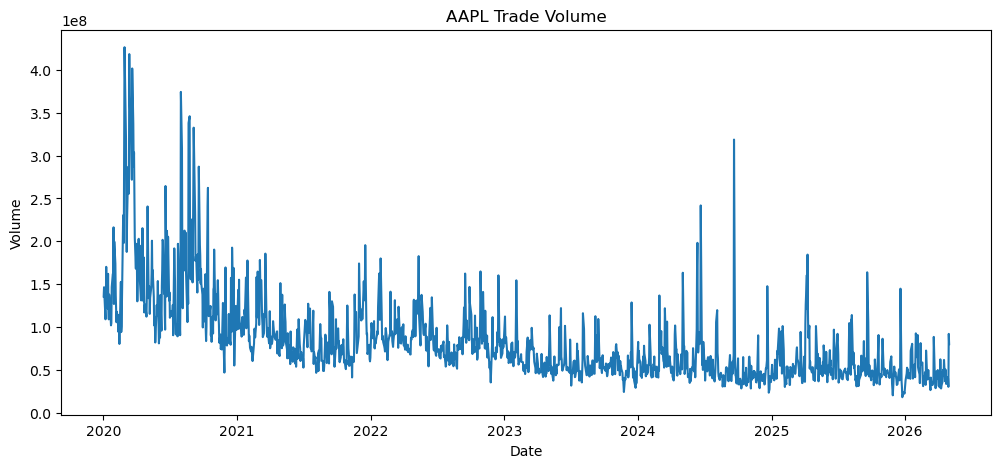

In [15]:
# Volume line plot
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Volume'])
plt.title('AAPL Trade Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

In [16]:
# Create Features
df['Return'] = df['Close'] / df['Close'].shift(1)
df['Log_Return'] = np.log(df['Return'])

df['Log_Volume'] = np.log(df['Volume'])
df['Lag_Log_Volume'] = df['Log_Volume'].shift(1)

df['Range_Pct'] = (df['High'] - df['Low']) / df['Close']
df['Lag_Range_Pct'] = df['Range_Pct'].shift(1)

df['Rolling_STD_5'] = (
    df['Log_Return'].rolling(5).std() # 5-day rolling standard deviation of log returns
) 
df['Lag_Rolling_STD_5'] = df['Rolling_STD_5'].shift(1)

In [17]:
# Drop Missing Values
df = df.dropna()

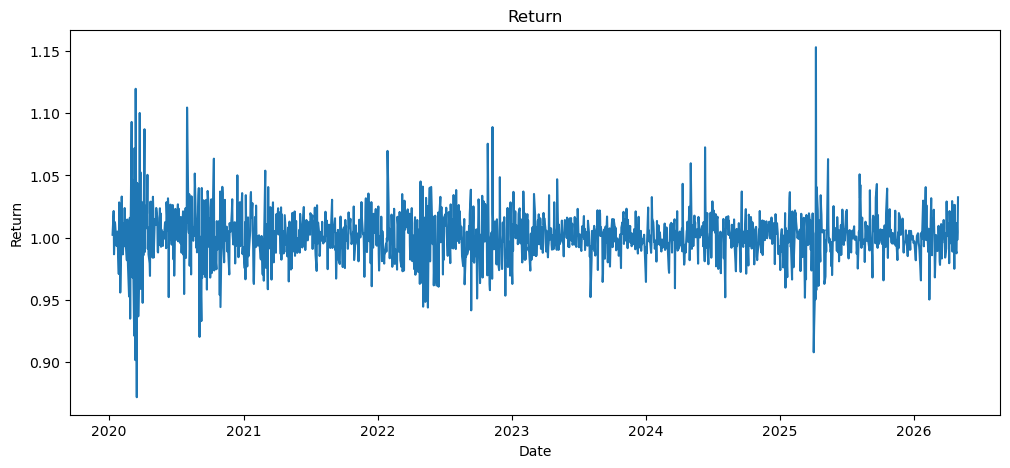

In [18]:
# Return
plt.figure(figsize=(12,5))

plt.plot(df.index, df['Return'])

plt.title('Return')
plt.xlabel('Date')
plt.ylabel('Return')

plt.show()

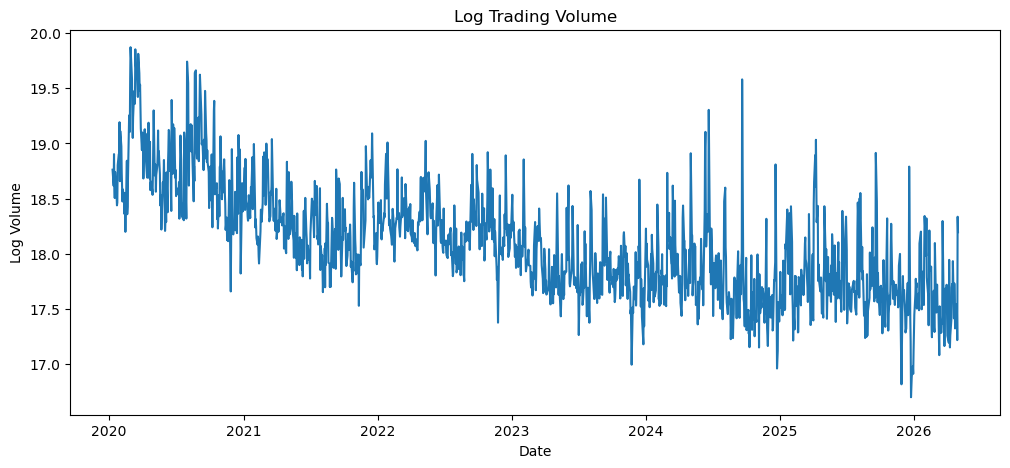

In [19]:
# Log Volume
plt.figure(figsize=(12,5))

plt.plot(df.index, df['Log_Volume'])

plt.title('Log Trading Volume')
plt.xlabel('Date')
plt.ylabel('Log Volume')

plt.show()

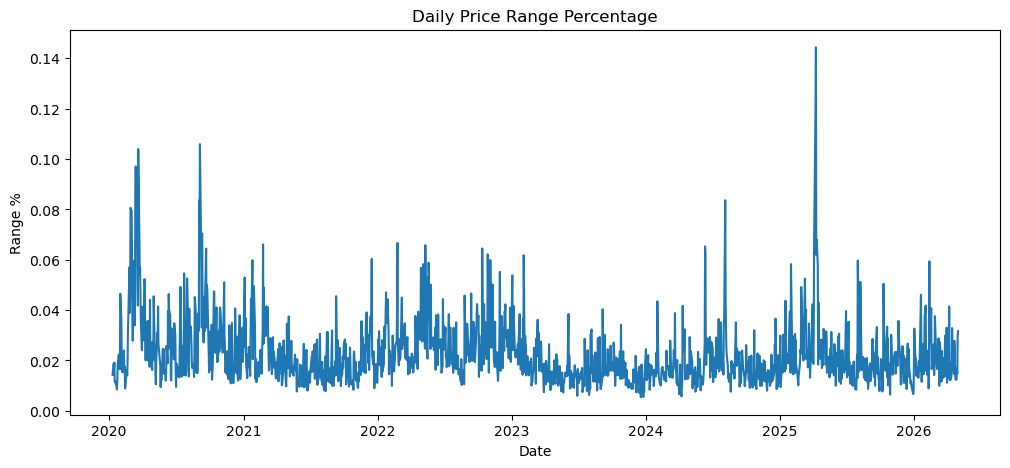

In [20]:
# Price Range Percentage
plt.figure(figsize=(12,5))

plt.plot(df.index, df['Range_Pct'])

plt.title('Daily Price Range Percentage')
plt.xlabel('Date')
plt.ylabel('Range %')

plt.show()

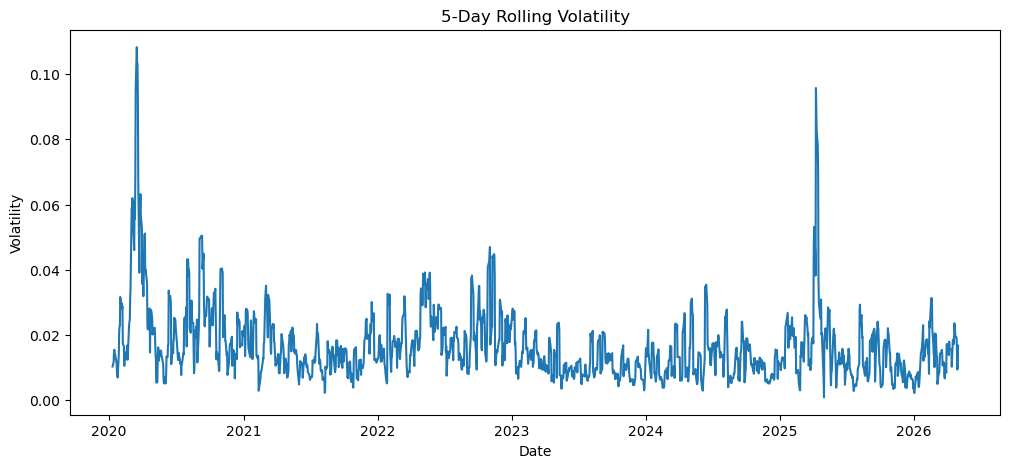

In [21]:
# Rolling volatility
plt.figure(figsize=(12,5))

plt.plot(df.index, df['Rolling_STD_5'])

plt.title('5-Day Rolling Volatility')

plt.xlabel('Date')
plt.ylabel('Volatility')

plt.show()

#### ARIMA for Return

In [22]:
data = df['Log_Return']

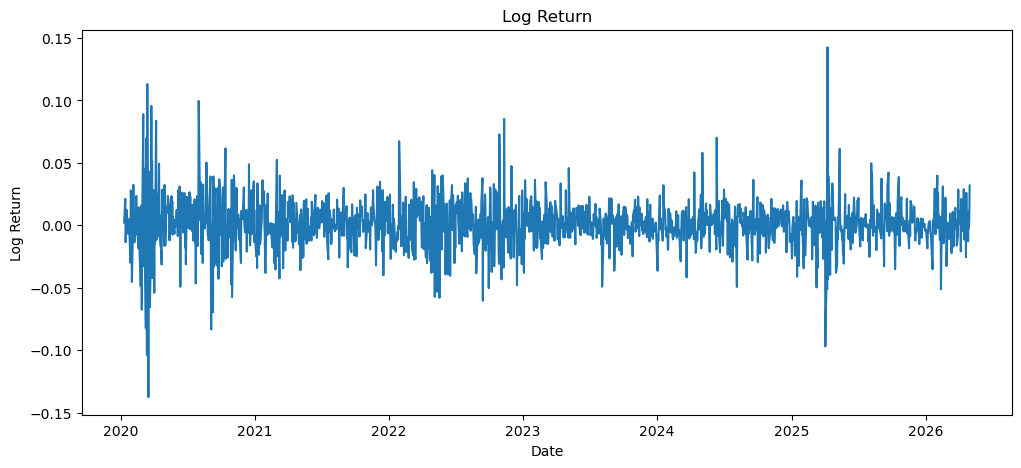

In [23]:
# Percentage return line plot
plt.figure(figsize=(12,5))
plt.plot(df.index, data)
plt.title('Log Return')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.show()

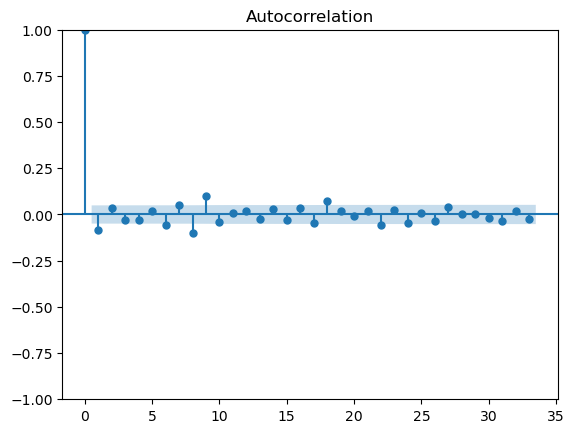

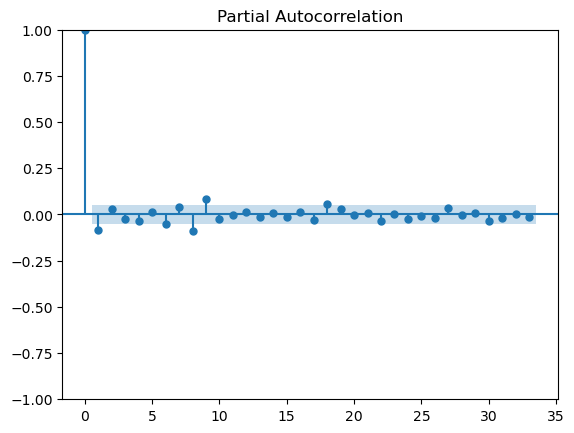

In [24]:
# ACF and PACF plots
plot_acf(data)
plot_pacf(data)
plt.show()

In [25]:
# Augmented Dickey–Fuller test
result = adfuller(data)
print(result[1])

4.231918452140205e-25


In [26]:
# Train-Test split
train_size = int(len(data) * 0.8)

train = data[:train_size]
test = data[train_size:]

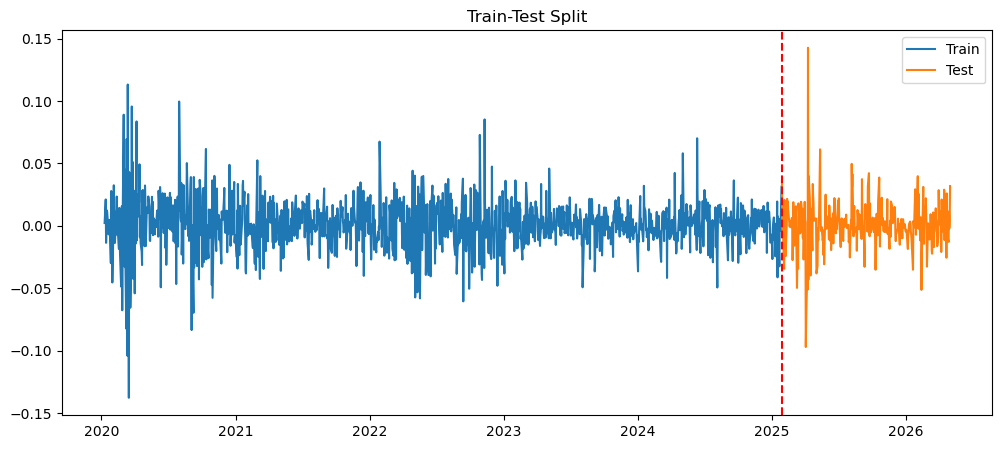

In [27]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')

plt.axvline(test.index[0], color='red', linestyle='--')

plt.legend()
plt.title("Train-Test Split")
plt.show()

In [28]:
# Fit ARIMA model
model1 = ARIMA(train, order=(0,0,0))
model_arima = model1.fit()

print(model_arima.summary())

                               SARIMAX Results                                
Dep. Variable:             Log_Return   No. Observations:                 1268
Model:                          ARIMA   Log Likelihood                3164.518
Date:                Fri, 29 May 2026   AIC                          -6325.037
Time:                        16:42:21   BIC                          -6314.746
Sample:                             0   HQIC                         -6321.171
                               - 1268                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.001      1.565      0.118      -0.000       0.002
sigma2         0.0004   8.29e-06     47.998      0.000       0.000       0.000
Ljung-Box (L1) (Q):                  16.27   Jarque-

C:\Users\META\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\META\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\META\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


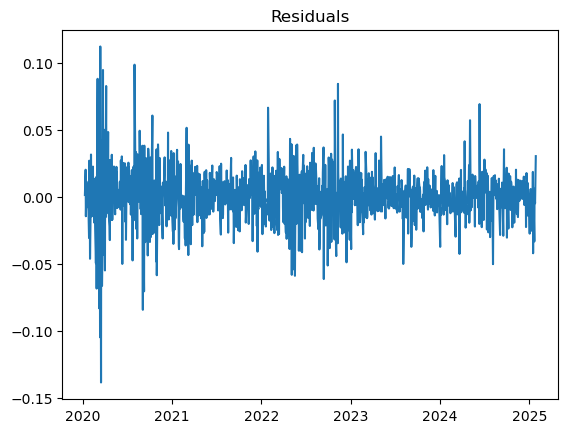

In [29]:
# Residual Plot
arima_residuals = model_arima.resid

plt.plot(arima_residuals)
plt.title("Residuals")
plt.show()

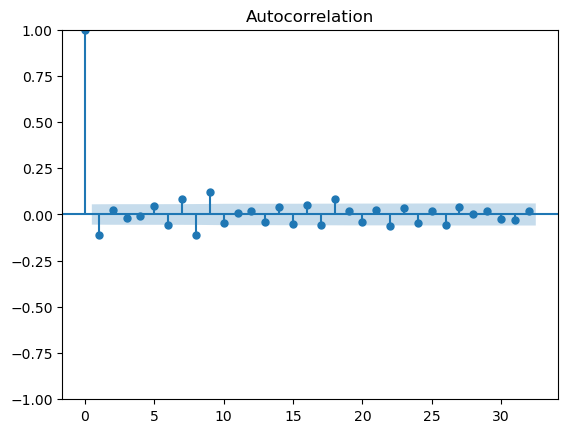

In [30]:
# Residual ACF plot
plot_acf(arima_residuals)
plt.show()

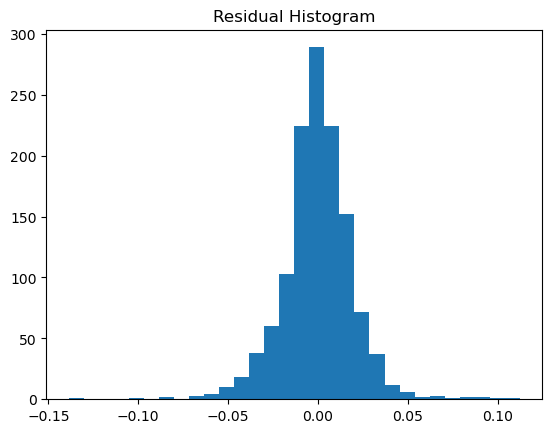

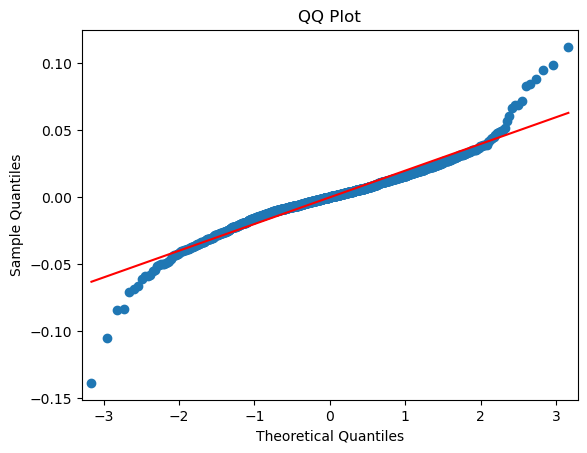

In [31]:
# Histogram of residuals
plt.hist(arima_residuals, bins=30)
plt.title("Residual Histogram")
plt.show()

# QQ plot
sm.qqplot(arima_residuals, line='s')
plt.title("QQ Plot")
plt.show()

In [32]:
# Ljung-Box
ljung_box = acorr_ljungbox(arima_residuals, lags=[10], return_df=True)
print(ljung_box)

      lb_stat     lb_pvalue
10  70.028836  4.377303e-11


In [33]:
# Make predictions
arima_predictions = model_arima.forecast(steps=len(test))

C:\Users\META\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\META\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [34]:
# Model Evaluation
arima_rmse = np.sqrt(mean_squared_error(test, arima_predictions))
mae = mean_absolute_error(test, arima_predictions)

print("RMSE:", arima_rmse)
print("MAE:", mae)

RMSE: 0.0192294825713819
MAE: 0.012359147520037837


In [35]:
# Naive Forecast
naive_forecast = test.shift(1).dropna()

naive_rmse = np.sqrt(
    mean_squared_error(
        test[1:],
        naive_forecast
    )
)

print("Naive RMSE:", naive_rmse)

Naive RMSE: 0.026483114688150983


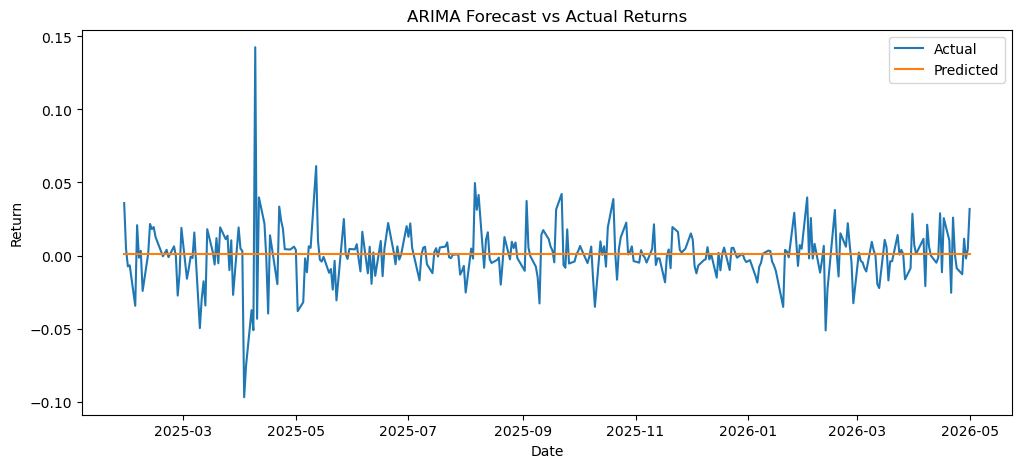

In [36]:
# Plot of the results
plt.figure(figsize=(12,5))

# Actual values
plt.plot(test.index, test, label='Actual')

# ARIMA predictions
plt.plot(test.index, arima_predictions, label='Predicted')
plt.title('ARIMA Forecast vs Actual Returns')
plt.xlabel('Date')
plt.ylabel('Return')

# Legend
plt.legend()

# Show plot
plt.show()

In [37]:
print(arima_predictions)

1268    0.000878
1269    0.000878
1270    0.000878
1271    0.000878
1272    0.000878
          ...   
1580    0.000878
1581    0.000878
1582    0.000878
1583    0.000878
1584    0.000878
Name: predicted_mean, Length: 317, dtype: float64


C:\Users\META\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\META\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


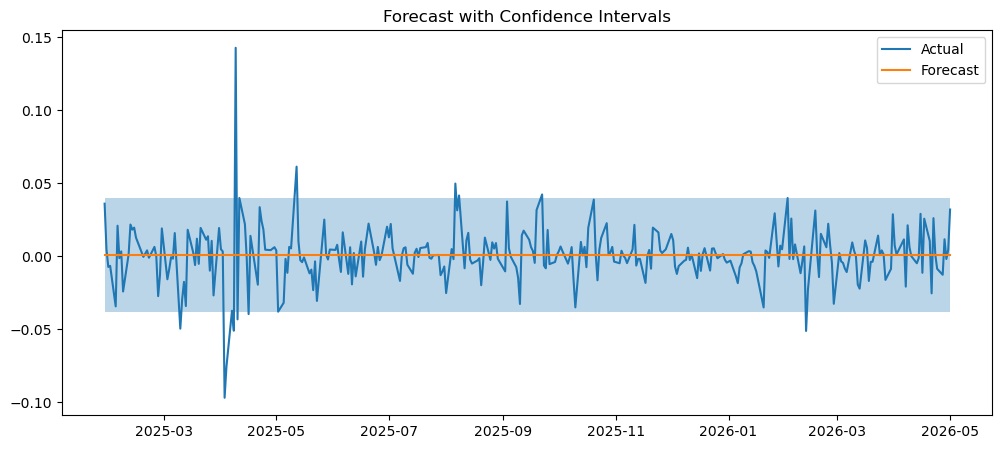

In [38]:
# Forecast with Confidence Interval
forecast_result = model_arima.get_forecast(steps=len(test))

forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

plt.figure(figsize=(12,5))

plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast_mean, label='Forecast')

plt.fill_between(
    test.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    alpha=0.3
)

plt.legend()
plt.title("Forecast with Confidence Intervals")
plt.show()

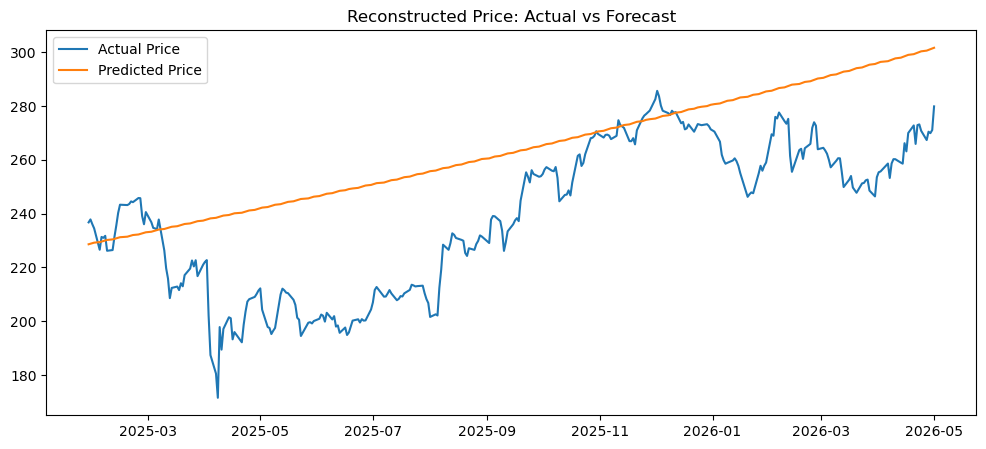

In [39]:
# Convert predicted returns into prices
last_known_price = df['Close'].iloc[train_size - 1]
predicted_prices = last_known_price * np.exp(arima_predictions.cumsum())
actual_prices    = last_known_price * np.exp(test.cumsum())

plt.figure(figsize=(12, 5))
plt.plot(test.index, actual_prices, label='Actual Price')
plt.plot(test.index, predicted_prices, label='Predicted Price')
plt.title('Reconstructed Price: Actual vs Forecast')
plt.legend()
plt.show()

### ARIMAX for Return

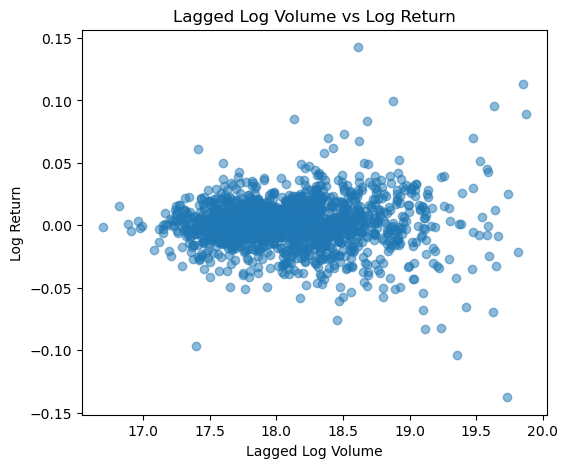

In [40]:
plt.figure(figsize=(6,5))

plt.scatter(df['Lag_Log_Volume'], df['Log_Return'], alpha=0.5)

plt.title('Lagged Log Volume vs Log Return')
plt.xlabel('Lagged Log Volume')
plt.ylabel('Log Return')

plt.show()

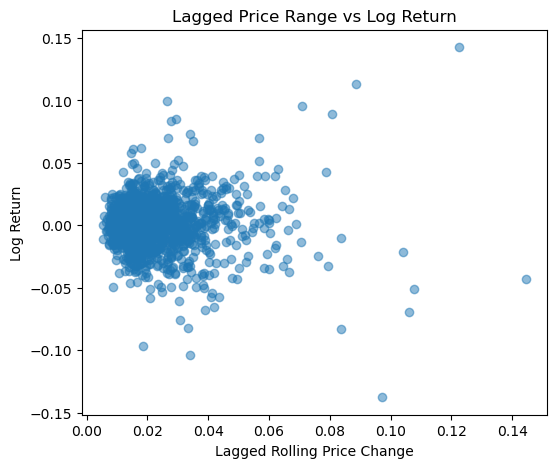

In [41]:
plt.figure(figsize=(6,5))

plt.scatter(df['Lag_Range_Pct'], df['Log_Return'], alpha=0.5)

plt.title('Lagged Price Range vs Log Return')
plt.xlabel('Lagged Rolling Price Change')
plt.ylabel('Log Return')

plt.show()

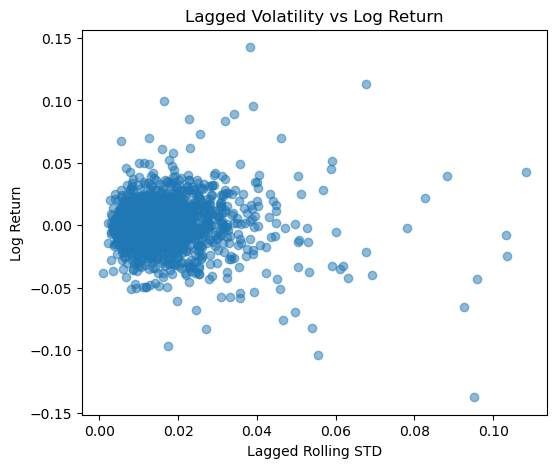

In [42]:
plt.figure(figsize=(6,5))

plt.scatter(df['Lag_Rolling_STD_5'], df['Log_Return'], alpha=0.5)

plt.title('Lagged Volatility vs Log Return')
plt.xlabel('Lagged Rolling STD')
plt.ylabel('Log Return')

plt.show()

In [43]:
# Target Variable
y = df['Log_Return']

In [44]:
# Exogenous Variables
X = df[['Lag_Log_Volume', 'Lag_Range_Pct', 'Lag_Rolling_STD_5']]

                   Log_Return  Lag_Log_Volume  Lag_Range_Pct  \
Log_Return           1.000000        0.022572       0.001032   
Lag_Log_Volume       0.022572        1.000000       0.612385   
Lag_Range_Pct        0.001032        0.612385       1.000000   
Lag_Rolling_STD_5   -0.050636        0.558872       0.618227   

                   Lag_Rolling_STD_5  
Log_Return                 -0.050636  
Lag_Log_Volume              0.558872  
Lag_Range_Pct               0.618227  
Lag_Rolling_STD_5           1.000000  


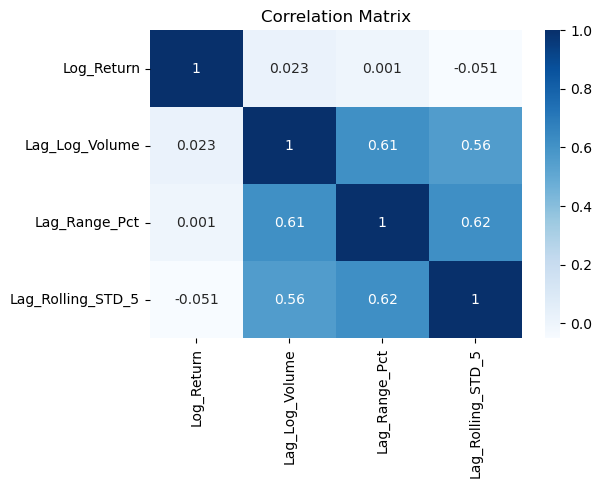

In [45]:
# Correlations with target variable
correlations = df[
    [
        'Log_Return',
        'Lag_Log_Volume',
        'Lag_Range_Pct',
        'Lag_Rolling_STD_5'
    ]
].corr()

print(correlations)

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(correlations, annot=True, cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

In [46]:
# Multicollinearity
X_vif = X.copy()

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_data)

             Feature       VIF
0     Lag_Log_Volume  4.571401
1      Lag_Range_Pct  6.615072
2  Lag_Rolling_STD_5  5.225865


In [47]:
# Train-Test split
train_size = int(len(df) * 0.8)

y_train = y[:train_size]
y_test = y[train_size:]

X_train = X[:train_size]
X_test = X[train_size:]

In [48]:
# Fit ARIMAX model
model2 = SARIMAX(
    y_train,
    exog=X_train,
    order=(2,0,2)
)
model_arimax = model2.fit()

print(model_arimax.summary())

C:\Users\META\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\META\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Log_Return   No. Observations:                 1268
Model:               SARIMAX(2, 0, 2)   Log Likelihood                3172.752
Date:                Fri, 29 May 2026   AIC                          -6329.504
Time:                        16:42:24   BIC                          -6288.343
Sample:                             0   HQIC                         -6314.041
                               - 1268                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Lag_Log_Volume        0.0001   5.53e-05      2.517      0.012    3.09e-05       0.000
Lag_Range_Pct         0.0475      0.039      1.224      0.221      -0.029       0.124
Lag_Rolling_STD_5    -0.

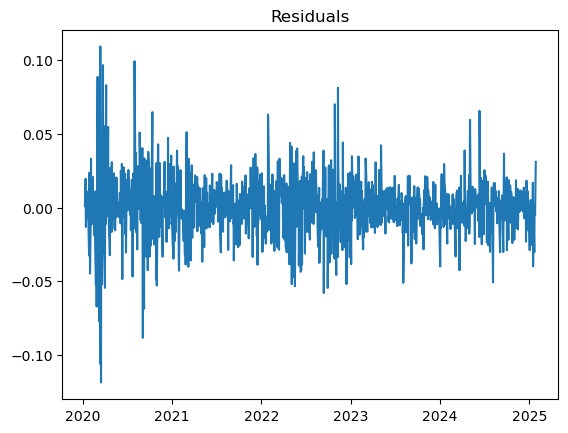

In [49]:
# Residual Plot
arimax_residuals = model_arimax.resid

plt.plot(arimax_residuals)
plt.title("Residuals")
plt.show()

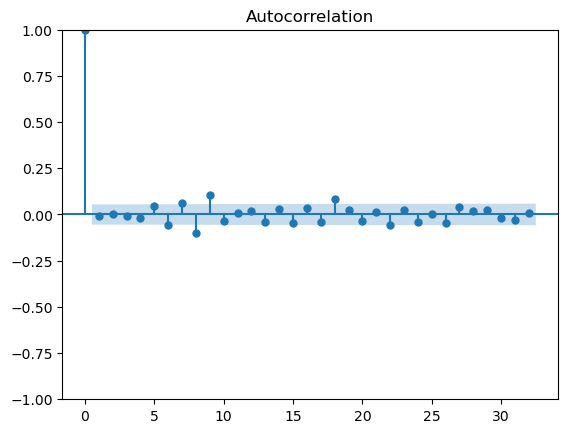

In [50]:
# Residual ACF plot
plot_acf(arimax_residuals)
plt.show()

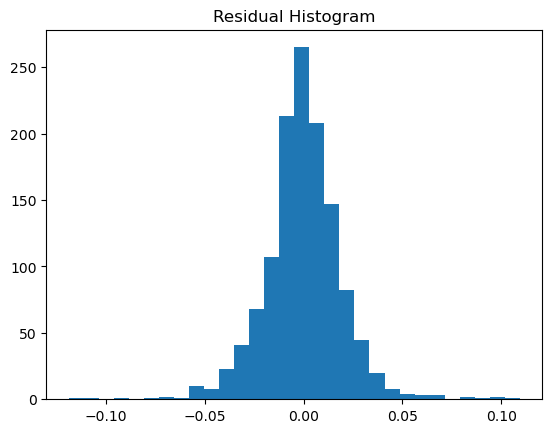

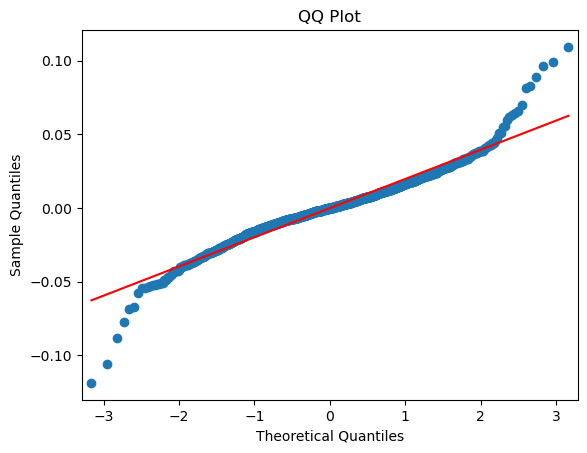

In [51]:
# Histogram of residuals
plt.hist(arimax_residuals, bins=30)
plt.title("Residual Histogram")
plt.show()

# QQ plot
sm.qqplot(arimax_residuals, line='s')
plt.title("QQ Plot")
plt.show()

In [52]:
# Ljung-Box
ljung_box = acorr_ljungbox(arimax_residuals, lags=[10], return_df=True)
print(ljung_box)

      lb_stat  lb_pvalue
10  40.705498   0.000013


In [53]:
# Make predictions
arimax_predictions = model_arimax.forecast(
    steps=len(y_test),
    exog=X_test
)

C:\Users\META\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\META\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [54]:
# RMSE
arimax_rmse = np.sqrt(mean_squared_error(y_test, arimax_predictions))
arimax_mae = mean_absolute_error(y_test, arimax_predictions)

print("RMSE:", arimax_rmse)
print("MAE:", arimax_mae)

RMSE: 0.019262460049164216
MAE: 0.012470731118507486


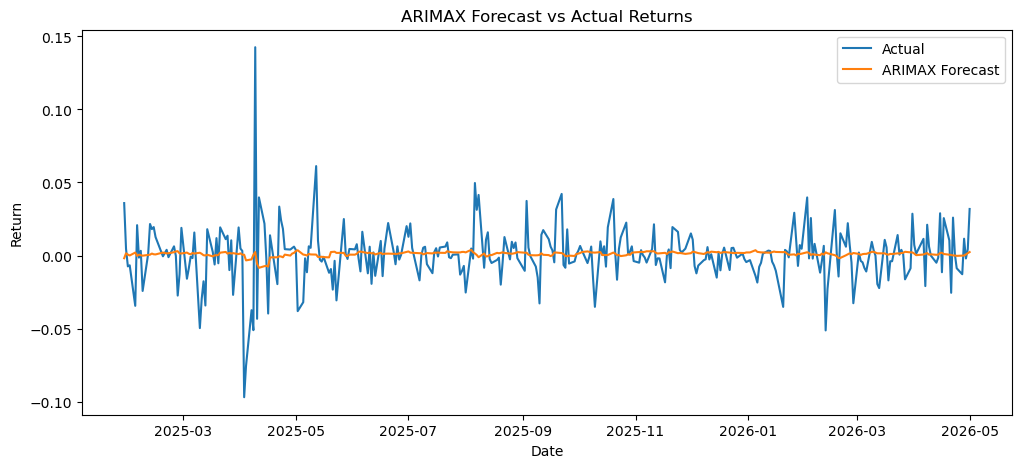

In [55]:
# Plot of results
plt.figure(figsize=(12,5))

# Actual values
plt.plot(y_test.index, y_test, label='Actual')

# ARIMAX predictions
plt.plot(y_test.index, arimax_predictions, label='ARIMAX Forecast')
plt.title('ARIMAX Forecast vs Actual Returns')
plt.xlabel('Date')
plt.ylabel('Return')

# Legend
plt.legend()

# Show plot
plt.show()

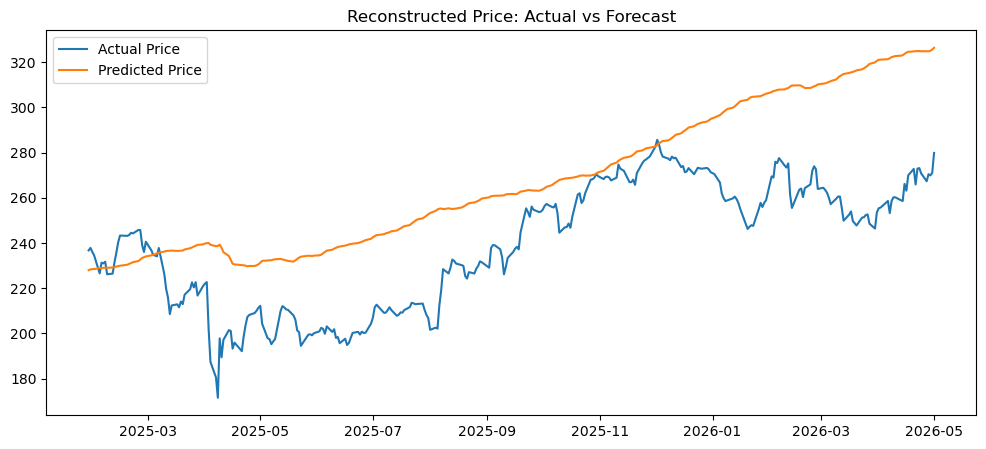

In [56]:
# Convert predicted returns into prices
last_known_price = df['Close'].iloc[train_size - 1]
predicted_prices = last_known_price * np.exp(arimax_predictions.cumsum())
actual_prices    = last_known_price * np.exp(y_test.cumsum())

plt.figure(figsize=(12, 5))
plt.plot(y_test.index, actual_prices, label='Actual Price')
plt.plot(y_test.index, predicted_prices, label='Predicted Price')
plt.title('Reconstructed Price: Actual vs Forecast')
plt.legend()
plt.show()